In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, balanced_accuracy_score

In [28]:
df_odi = pd.read_csv('virat_kohli_odi_innings_data.csv')
df_t20 = pd.read_csv("virat_kohli_t20i_innings_data.csv")
df_test = pd.read_csv('virat_kohli_test_innings_data.csv')

In [29]:
runs = np.concatenate((df_odi['Runs'], df_t20['Runs'], df_test['Runs']))
sr = np.concatenate((df_odi['SR'], df_t20['SR'], df_test['SR']))
ground = np.concatenate((df_odi['Ground'], df_t20['Ground'], df_test['Ground']))
match_type = np.concatenate((['ODI']*len(df_odi), ['T20I']*len(df_t20), ['Test']*len(df_test)))

In [30]:
data_cricketer = pd.DataFrame({
    'Runs': runs,
    'SR': sr,
    'Ground': ground,
    'Match_Type': match_type
})
#drop invalid numbers due to svc error
data_cricketer['Runs'] = pd.to_numeric(data_cricketer['Runs'], errors='coerce')
data_cricketer['SR'] = pd.to_numeric(data_cricketer['SR'], errors='coerce')
data_cricketer.dropna(inplace=True)

In [31]:
X = data_cricketer[['Runs', 'SR']] #no ground because its non numerical 
Y = data_cricketer['Match_Type']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=0)

In [32]:
svc = SVC(kernel='poly', degree=6)
svc.fit(X_train, Y_train)
Y_pred = svc.predict(X_test)

In [33]:
conf_mat = confusion_matrix(Y_test, Y_pred)
conf_mat

array([[48,  2, 23],
       [13, 17,  3],
       [ 1,  0, 53]])

In [34]:
acc_score = accuracy_score(Y_test, Y_pred)
acc_score

0.7375

In [35]:
bal_acc_score = balanced_accuracy_score(Y_test, Y_pred)
bal_acc_score

0.718055747736113

<Axes: >

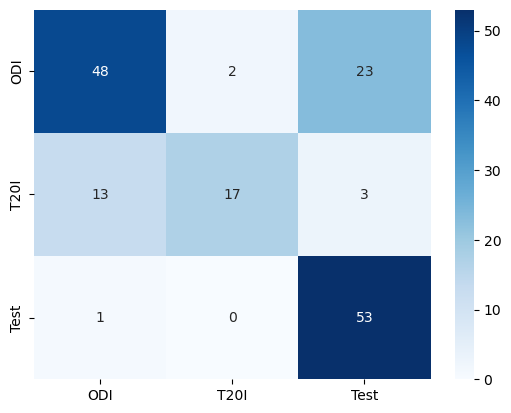

In [36]:
sns.heatmap(conf_mat, cmap='Blues', annot=True, xticklabels=svc.classes_, yticklabels=svc.classes_)

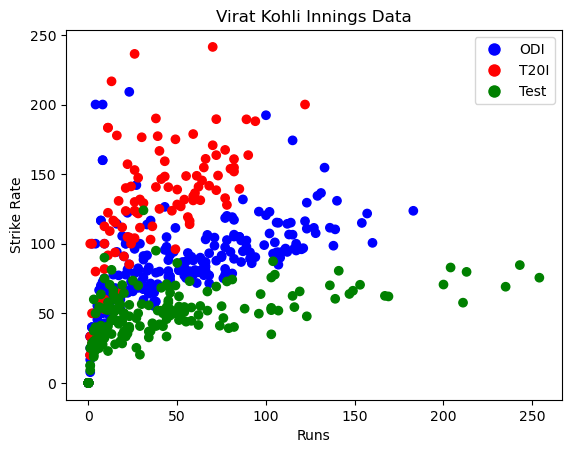

In [37]:
plt.scatter(X['Runs'], X['SR'], c=Y.map({'ODI': 'blue', 'T20I': 'red', 'Test': 'green'}))
plt.xlabel('Runs')
plt.ylabel('Strike Rate')
plt.title('Virat Kohli Innings Data')
plt.legend(handles=[plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label='ODI'),
                    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='T20I'),
                    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=10, label='Test')])
plt.show()

### What are Support Vectors in SVM? How do they help in making SVM less prone to outliers?
Support vectors are hyperplanes that divide the space into sections, based on the target classification. They help make the SVM less prone to outliers as decisions are determined by the decision boundary rather than individual points. Thus, if outliers exist, they do not affect the decision.

### What is the difference between a hard margin and a soft margin in SVM?
A hard margin is an SVM that requires the data to be correctly classified and allows for no misclassification. A soft margin allows for some misclassification of data points, which makes it more flexible in a real-world scenario.

### How does SVM deal with non-linear classification boundaries?
We can use the kernel trick to transform the data into a higher-dimensional space where it becomes linearly separable. Common kernels include the polynomial kernel, radial basis function (RBF) kernel, and sigmoid kernel.

### What is the role of gamma in SVM? How does the value of gamma impact underfitting/overfitting?
Gamma defines how far the influence of a single training example reaches. A low gamma value means a larger influence, leading to underfitting. A high gamma value means a smaller influence, leading to overfitting.

### How are SVMs used for multi-class classification problems?
SVMs are inherently binary classifiers. For multi-class problems, we use strategies like one-vs-rest (OvR) or one-vs-one (OvO). In OvR, we train one classifier per class against all others. In OvO, we train classifiers for every pair of classes and combine their results.